# Submission Summary

| Item | Information |
|---|---|
| Group number | 28 |
| Your full name | NULL |
| Dataset | Stroke Prediction |
| Depth track | To be determined |
| Team members | To be added |
| Final model | To be determined |
| Stratified dummy F1 / ROC AUC | To be determined |
| Final model F1 / ROC AUC | To be determined |
| Leakage columns dropped | To be determined |
| Full run time on Colab | To be determined |

In [2]:
!pip install -q kagglehub

In [3]:
import kagglehub

In [4]:
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.


In [5]:
print(path)

/kaggle/input/stroke-prediction-dataset


In [6]:
import os
os.listdir(path)

['healthcare-dataset-stroke-data.csv']

In [7]:
import pandas as pd

In [8]:
file_path = os.path.join(path, "healthcare-dataset-stroke-data.csv")
df = pd.read_csv(file_path)

In [9]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [10]:
df.shape

(5110, 12)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [12]:
missing_bmi = df["bmi"].isnull().sum()
missing_bmi_percentage = (missing_bmi / len(df)) * 100

print("Missing BMI:", missing_bmi)
print("Percentage missing:", missing_bmi_percentage)

Missing BMI: 201
Percentage missing: 3.9334637964774952


In [13]:
df.groupby(df["bmi"].isnull())["stroke"].mean()

,stroke
bmi,
False,0.042575
True,0.199005


In [14]:
df.groupby(df["bmi"].isnull())["age"].mean()

,age
bmi,
False,42.865374
True,52.049154


In [15]:
df["bmi"].describe()

,bmi
count,4909.000000
mean,28.893237
std,7.854067
min,10.300000
25%,23.500000
50%,28.100000
75%,33.100000
max,97.600000


In [16]:
median_bmi = df["bmi"].median()
df["bmi"] = df["bmi"].fillna(median_bmi)

In [17]:
df["bmi"].isnull().sum()

np.int64(0)

In [18]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [19]:
df["stroke"].value_counts()

,count
stroke,
0,4861
1,249


In [20]:
df["stroke"].value_counts(normalize=True) * 100

,proportion
stroke,
0,95.127202
1,4.872798


In [21]:
df["age"].describe()

,age
count,5110.000000
mean,43.226614
std,22.612647
min,0.080000
25%,25.000000
50%,45.000000
75%,61.000000
max,82.000000


### Age Distribution:

The dataset contains individuals across a broad range of ages, from infants to 82 years old. The average age is approximately 43 years, while the median age is 45 years.

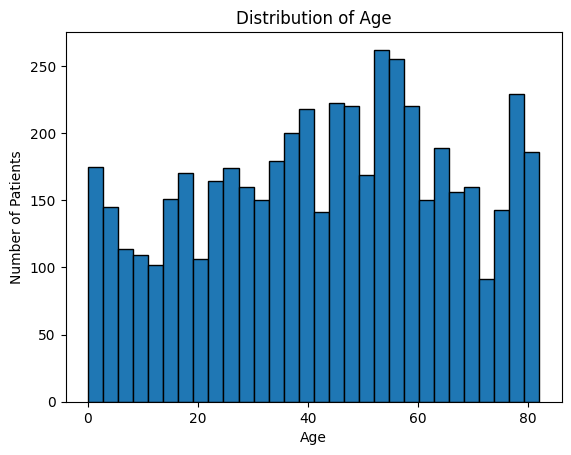

In [22]:
import matplotlib.pyplot as plt

plt.hist(df["age"], bins=30, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Distribution of Age")
plt.show()

In [23]:
df["avg_glucose_level"].describe()

,avg_glucose_level
count,5110.000000
mean,106.147677
std,45.283560
min,55.120000
25%,77.245000
50%,91.885000
75%,114.090000
max,271.740000


### Average Glucose Level Distribution:

The distribution is right-skewed. Most patients have lower to moderate glucose levels, while a smaller number have much higher values, which pulls the mean above the median.

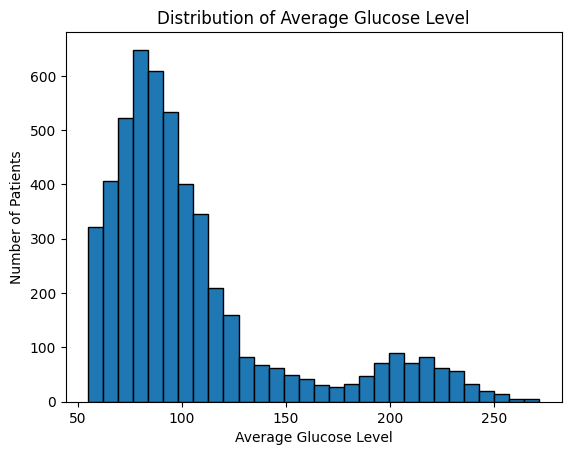

In [24]:
plt.hist(df["avg_glucose_level"], bins=30, edgecolor="black")
plt.xlabel("Average Glucose Level")
plt.ylabel("Number of Patients")
plt.title("Distribution of Average Glucose Level")
plt.show()

In [25]:
df["bmi"].describe()

,bmi
count,5110.000000
mean,28.862035
std,7.699562
min,10.300000
25%,23.800000
50%,28.100000
75%,32.800000
max,97.600000


### BMI Distribution:

BMI is slightly right-skewed, with most observations concentrated around the mid-20s to low-30s. A few unusually high BMI values are present, including a maximum of 97.6. These values were retained because a high value alone is not sufficient evidence that the observation is incorrect.

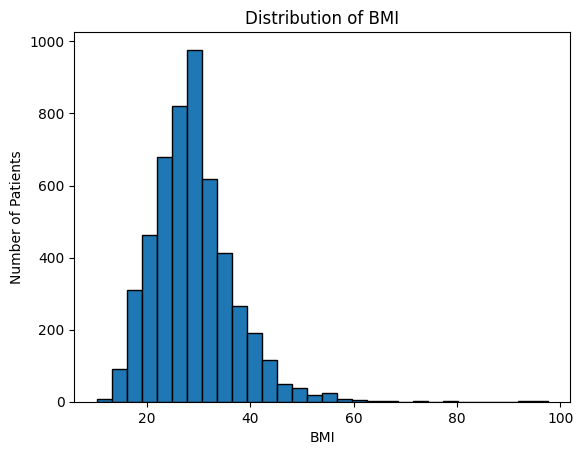

In [26]:
plt.hist(df["bmi"], bins=30, edgecolor="black")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.title("Distribution of BMI")
plt.show()

In [27]:
df["smoking_status"].value_counts()

,count
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,885
smokes,789


In [28]:
df["smoking_status"].value_counts(normalize=True) * 100

,proportion
smoking_status,
never smoked,37.025440
Unknown,30.215264
formerly smoked,17.318982
smokes,15.440313


### Smoking Status Distribution:

The largest group consists of individuals who never smoked (37.0%), followed by individuals with unknown smoking status (30.2%). Former smokers account for 17.3%, while current smokers account for 15.4%. The relatively large Unknown category should be retained as a separate category because it represents unavailable information rather than confirmed non-smoking.

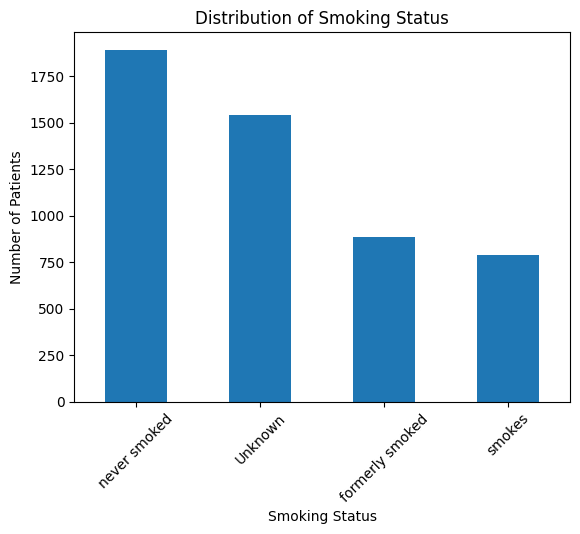

In [29]:
df["smoking_status"].value_counts().plot(kind="bar")

plt.xlabel("Smoking Status")
plt.ylabel("Number of Patients")
plt.title("Distribution of Smoking Status")
plt.xticks(rotation=45)
plt.show()

In [30]:
df["hypertension"].value_counts()

,count
hypertension,
0,4612
1,498


### Hypertension Distribution:

Most individuals in the dataset do not have hypertension (90.3%), while approximately 9.7% have hypertension. Although the column is stored as an integer, it represents a binary categorical variable where 0 means no hypertension and 1 means hypertension.

In [31]:
df["hypertension"].value_counts(normalize=True) * 100

,proportion
hypertension,
0,90.254403
1,9.745597


### Duplicate Check:

No exact duplicate rows were found in the dataset, so no rows were removed for duplication.

In [32]:
df.duplicated().sum()

np.int64(0)